# Elastic Net — Multi-Horizon WTI Forecasting

## Overview
Elastic Net combines L1 (LASSO) and L2 (Ridge) penalties to perform regularized regression with grouped variable selection. It is well-suited for our setting because the 31 macro features × 30 lags = 930+ features create a high-dimensional, multicollinear predictor space.

### Key Design Decisions
- **Why Elastic Net over pure LASSO?** With 31 macro series that are often highly correlated (e.g., GS1, GS5, GS10 are all Treasury yields), LASSO arbitrarily picks one from a correlated group. Elastic Net retains groups of correlated predictors together, producing more stable forecasts.
- **Multi-horizon**: We run h=1 (daily), h=5 (weekly), and h=20 (monthly) to test whether monthly macro data has more signal at longer horizons.
- **Naive baseline**: Predicting zero (random walk) is included as a sanity check — any model that can't beat this has no value.

## 1. Imports

In [1]:
# ============================================================
# Imports
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import time
from abc import ABC, abstractmethod
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

## 2. Base Forecast Model

In [2]:
# ============================================================
# Base Forecast Model
# ============================================================
class BaseForecastModel(ABC):
    """Abstract base class shared by all models (EN, XGB, VAR, LSTM)."""
    def __init__(self, task_type: str):
        self.task_type = task_type

    @abstractmethod
    def fit(self, *args, **kwargs): pass

    @abstractmethod
    def predict(self, X): pass

    @abstractmethod
    def evaluate(self, X, y): pass

    @abstractmethod
    def save(self, filepath: str): pass

    @abstractmethod
    def load(self, filepath: str): pass

## 3. Evaluation Metrics

In [3]:
# ============================================================
# Evaluation Metrics
# ============================================================
def rmse(y, yhat):
    """Root Mean Squared Error."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def mae(y, yhat):
    """Mean Absolute Error."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return float(np.mean(np.abs(y - yhat)))

def r2(y, yhat):
    """R-squared. Negative = worse than predicting the mean."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    ss_tot = np.sum((y - y.mean()) ** 2)
    ss_res = np.sum((y - yhat) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan

def directional_accuracy(y, yhat):
    """Fraction where predicted and actual signs match. 50% = random."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return float(np.mean(np.sign(y) == np.sign(yhat)))

## 4. Data Helpers (Trading-Day Aligned)
All models in this project now use the same alignment strategy: macro data is forward-filled onto `price.index` (actual WTI trading days). This eliminates the previous inconsistency where Elastic Net used calendar days (`freq="D"`) while XGBoost and LSTM used trading days.

In [4]:
# ============================================================
# Data Helpers (STRICT leakage control — trading-day aligned)
# ============================================================
# FIX: All models now use price.index for daily alignment
# instead of freq="D" (calendar) or freq="B" (business days).
# This ensures all models are evaluated on exactly the same dates.

def load_macro_monthly(path: Path, features: list[str]) -> pd.DataFrame:
    """Load FRED-MD monthly macro data, keeping only specified features.
    Skips the metadata row present in FRED-MD CSVs."""
    df = pd.read_csv(path, skiprows=[1]).rename(columns={"sasdate": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    keep = [c for c in features if c in df.columns]
    missing = [c for c in features if c not in df.columns]
    if missing:
        print(f"[WARN] Missing macro columns (skipped): {missing}")
    return df[keep].copy()


def load_price(path: Path) -> pd.Series:
    """Load WTI crude oil daily price data (trading days only)."""
    px = pd.read_csv(path, parse_dates=["Date"])
    return px.set_index("Date")["Price"].sort_index()


def make_lagged_features(X: pd.DataFrame, L: int) -> pd.DataFrame:
    """Create L lagged versions of each column in X.
    Lag 1 = yesterday, Lag 2 = two days ago, etc."""
    return pd.concat(
        [X.shift(l).add_suffix(f"_lag{l:02d}") for l in range(1, L + 1)],
        axis=1
    ).dropna()


def daily_log_return(price: pd.Series) -> pd.Series:
    """Compute daily log returns: log(P_t) - log(P_{t-1})."""
    return np.log(price.astype(float)).diff().rename("ret_1d")


def make_target(price: pd.Series, horizon: int = 1) -> pd.Series:
    """h-day-ahead log return target: y_t = log(P_{t+h}) - log(P_t)."""
    price = price.astype(float)
    return (np.log(price.shift(-horizon)) - np.log(price)).rename("y")

## 5. Feature Engineering

In [5]:
# ============================================================
# (make_lagged_features and make_target are defined above)
# No additional feature engineering needed — lagged features
# are constructed inside build_dataset.
# ============================================================

## 6. Dataset Builder

In [6]:
# ============================================================
# Trading-Day Aligned Dataset Builder
# ============================================================
def build_dataset(
    macro_file: Path,
    price_file: Path,
    features: list[str],
    lookback: int = 30,
    horizon: int = 1,
    train_end: str = "2014-12-31",
    val_end: str = "2024-12-31",
):
    """Build leakage-safe train/val/test datasets aligned to WTI trading days.

    Pipeline:
        1. Load monthly macro → shift by 1 month (anti-leakage)
        2. Align to WTI trading days via forward-fill on price.index
        3. Create 30-day lagged features (flattened for tabular models)
        4. Compute h-day-ahead log return target
        5. Split chronologically

    Args:
        horizon: Forecast horizon in trading days (1, 5, or 20)
    """
    # Load macro and apply anti-leakage shift
    macro_m = load_macro_monthly(macro_file, features)
    macro_m.index = macro_m.index + pd.offsets.MonthBegin(1)

    # Load prices (trading days only)
    price = load_price(price_file)

    # FIX: Align macro directly to trading-day index (no synthetic dates)
    macro_d = macro_m.reindex(price.index, method="ffill")

    # Combine macro + price on common trading days
    base = macro_d.join(price, how="inner").dropna()

    # Add daily log return as momentum feature
    base["ret_1d"] = np.log(base["Price"]).diff()

    # Create lagged features
    X_macro = make_lagged_features(base[features], lookback)
    X_price = make_lagged_features(base[["ret_1d"]], lookback)
    X = X_macro.join(X_price).dropna()

    # Forward return target at specified horizon
    y = make_target(base["Price"], horizon=horizon)

    # Align X and y
    y = y.reindex(X.index).dropna()
    X = X.loc[y.index]

    # Chronological split
    train_end_ts = pd.Timestamp(train_end)
    val_end_ts = pd.Timestamp(val_end)
    tr = X.index <= train_end_ts
    va = (X.index > train_end_ts) & (X.index <= val_end_ts)
    te = X.index > val_end_ts

    return (
        X.loc[tr], y.loc[tr],
        X.loc[va], y.loc[va],
        X.loc[te], y.loc[te],
    )

## 7. Naive Baseline

In [7]:
# ============================================================
# Naive Baseline — Predict Zero
# ============================================================
# The naive baseline predicts zero return for all dates.
# This is equivalent to the random walk hypothesis: P_{t+h} = P_t.
# Any model that can't beat this has no predictive value.
# R² is implicitly measured against this baseline, but having explicit
# metrics makes the comparison concrete.

def naive_baseline_metrics(y):
    """Evaluate the naive 'predict zero' baseline."""
    y = np.asarray(y, float)
    pred = np.zeros_like(y)
    return {
        "rmse": rmse(y, pred),
        "mae": mae(y, pred),
        "r2": r2(y, pred),
        "directional_acc": 0.5,  # random by definition
    }

## 8. Elastic Net Model Class
The model performs a grid search over `alpha` (regularization strength) and `l1_ratio` (L1 vs L2 mix) using 5-fold TimeSeriesSplit CV. The scaler is fit per-fold to prevent leakage, then refit on all training data for the final model.

In [8]:
# ============================================================
# Elastic Net Forecast Model
# ============================================================
class ElasticNetForecastModel(BaseForecastModel):
    """Elastic Net with TimeSeriesSplit CV for hyperparameter selection.

    Grid: 10 alphas × 3 l1_ratios = 30 configs × 5 folds = 150 fits.
    """
    def __init__(
        self,
        alphas=np.logspace(-2, 1, 10),
        l1_ratios=[0.2, 0.5, 0.8],
        n_splits=5,
        max_iter=20000,
    ):
        super().__init__("regression")
        self.alphas = alphas
        self.l1_ratios = l1_ratios
        self.n_splits = n_splits
        self.max_iter = max_iter
        self.scaler = None
        self.model = None
        self.best_params_ = None
        self.cv_results_ = []
        self.feature_names_ = None

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series):
        """CV grid search then refit on full training data."""
        self.feature_names_ = list(X_train.columns)
        X, y = X_train.values, y_train.values
        tscv = TimeSeriesSplit(n_splits=self.n_splits)
        best_rmse = np.inf
        self.cv_results_ = []

        for a in self.alphas:
            for l1 in self.l1_ratios:
                fold_rmses = []
                for tr, va in tscv.split(X):
                    sc = StandardScaler()
                    Xtr = sc.fit_transform(X[tr])
                    Xva = sc.transform(X[va])
                    m = ElasticNet(alpha=a, l1_ratio=l1, max_iter=self.max_iter)
                    m.fit(Xtr, y[tr])
                    fold_rmses.append(rmse(y[va], m.predict(Xva)))

                mean_r = np.mean(fold_rmses)
                self.cv_results_.append({"alpha": a, "l1_ratio": l1, "rmse": mean_r})
                if mean_r < best_rmse:
                    best_rmse = mean_r
                    self.best_params_ = {"alpha": a, "l1_ratio": l1, "cv_rmse": mean_r}

        # Final refit on all training data
        self.scaler = StandardScaler()
        Xs = self.scaler.fit_transform(X)
        self.model = ElasticNet(
            alpha=self.best_params_["alpha"],
            l1_ratio=self.best_params_["l1_ratio"],
            max_iter=self.max_iter, random_state=42,
        )
        self.model.fit(Xs, y)
        return self

    def predict(self, X):
        return self.model.predict(self.scaler.transform(X.values))

    def evaluate(self, X, y):
        p = self.predict(X)
        return {
            "rmse": rmse(y.values, p), "mae": mae(y.values, p),
            "r2": r2(y.values, p), "directional_acc": directional_accuracy(y.values, p),
        }

    def coef_table(self, top_n=20):
        """Return top coefficients by absolute magnitude."""
        df = pd.DataFrame({"feature": self.feature_names_, "coef": self.model.coef_})
        df["abs"] = df["coef"].abs()
        return df.sort_values("abs", ascending=False).head(top_n).drop(columns="abs")

    def save(self, path):
        with open(path, "wb") as f: pickle.dump(self.__dict__, f)

    def load(self, path):
        with open(path, "rb") as f: self.__dict__.update(pickle.load(f))

## 9. Configuration

In [9]:
# ============================================================
# Configuration
# ============================================================
MACRO_FILE = Path("MD_Test/2025-12-MD.csv")
PRICE_FILE = Path("Price/Price.csv")

# 31 VIP macro features spanning real activity, monetary policy,
# yield curve, credit spreads, exchange rates, and sentiment
FEATURES = [
    "RPI","W875RX1","CMRMTSPLx","IPFPNSS","USWTRADE","USTRADE","BUSLOANS",
    "CONSPI","S&P 500","S&P PE ratio","FEDFUNDS","TB3MS","TB6MS","GS1","GS5",
    "GS10","AAA","BAA","TB3SMFFM","TB6SMFFM","T1YFFM","T5YFFM","T10YFFM",
    "AAAFFM","BAAFFM","EXSZUSx","EXJPUSx","EXUSUKx","EXCAUSx",
    "PPICMM","UMCSENTx"
]

HORIZONS = [1, 5, 20]

## 10. Multi-Horizon Training
Run Elastic Net at h=1, 5, 20. For each horizon, build the dataset, run CV, fit final model, evaluate, and store results.

In [10]:
# ============================================================
# Multi-Horizon Training
# ============================================================
results = {}

for h in HORIZONS:
    print(f"\n{'='*60}")
    print(f"  HORIZON = {h} day(s)")
    print(f"{'='*60}")
    t0 = time.time()

    Xtr, ytr, Xva, yva, Xte, yte = build_dataset(
        MACRO_FILE, PRICE_FILE, FEATURES,
        lookback=30, horizon=h,
    )

    print(f"  Train: {Xtr.shape}  Val: {Xva.shape}  Test: {Xte.shape}")

    model = ElasticNetForecastModel()
    model.fit(Xtr, ytr)

    pred_val = model.predict(Xva)
    pred_test = model.predict(Xte)
    val_m = model.evaluate(Xva, yva)
    test_m = model.evaluate(Xte, yte)
    naive_val = naive_baseline_metrics(yva.values)
    naive_test = naive_baseline_metrics(yte.values)
    elapsed = time.time() - t0

    results[h] = {
        'Xtr': Xtr, 'ytr': ytr, 'Xva': Xva, 'yva': yva, 'Xte': Xte, 'yte': yte,
        'pred_val': pred_val, 'pred_test': pred_test,
        'val_metrics': val_m, 'test_metrics': test_m,
        'naive_val': naive_val, 'naive_test': naive_test,
        'model': model, 'elapsed': elapsed,
    }

    print(f"  Best params: {model.best_params_}")
    print(f"  Validation:  {val_m}")
    print(f"  Test:        {test_m}")
    print(f"  Naive (val): {naive_val}")
    print(f"  Naive (test):{naive_test}")
    print(f"  Time: {elapsed:.1f}s")
    model.save(f"elasticnet_wti_h{h}.pkl")

print("\nAll horizons complete.")


  HORIZON = 1 day(s)
  Train: (7953, 960)  Val: (2635, 960)  Test: (215, 960)
  Best params: {'alpha': np.float64(0.01), 'l1_ratio': 0.5, 'cv_rmse': np.float64(0.023600134281789836)}
  Validation:  {'rmse': 0.03087045206701859, 'mae': 0.018476710974024268, 'r2': -1.1556045509397705e-06, 'directional_acc': 0.5294117647058824}
  Test:        {'rmse': 0.020521767599021454, 'mae': 0.015157029224723098, 'r2': -0.001840276312667699, 'directional_acc': 0.4930232558139535}
  Naive (val): {'rmse': 0.03087062275732469, 'mae': 0.018481105258168637, 'r2': -1.221413876817401e-05, 'directional_acc': 0.5}
  Naive (test):{'rmse': 0.02051870164530729, 'mae': 0.015155986859646992, 'r2': -0.001540948639941364, 'directional_acc': 0.5}
  Time: 15.2s

  HORIZON = 5 day(s)
  Train: (7953, 960)  Val: (2635, 960)  Test: (211, 960)
  Best params: {'alpha': np.float64(0.021544346900318832), 'l1_ratio': 0.2, 'cv_rmse': np.float64(0.05048487123737344)}
  Validation:  {'rmse': 0.059009155787829254, 'mae': 0.040071

## 11. Comparison Table

In [11]:
# ============================================================
# Comparison Table (with Naive Baseline)
# ============================================================
print("\n" + "=" * 85)
print("  ELASTIC NET MULTI-HORIZON COMPARISON")
print("=" * 85)

header = f"{'Horizon':>8} | {'Model':>8} | {'Split':>5} | {'RMSE':>10} | {'MAE':>10} | {'R²':>10} | {'Dir Acc':>10}"
print(header)
print("-" * len(header))

for h in HORIZONS:
    r = results[h]
    for model_name, vm, tm in [
        ("EN", r["val_metrics"], r["test_metrics"]),
        ("Naive", r["naive_val"], r["naive_test"]),
    ]:
        for sn, m in [("Val", vm), ("Test", tm)]:
            print(f"  h={h:>2}d   | {model_name:>8} | {sn:>5} | "
                  f"{m['rmse']:>10.6f} | {m['mae']:>10.6f} | "
                  f"{m['r2']:>10.6f} | {m['directional_acc']:>10.4f}")
    print("-" * len(header))

print("\nBest configs:")
for h in HORIZONS:
    bp = results[h]['model'].best_params_
    print(f"  h={h:>2}d: alpha={bp['alpha']:.4f}, l1_ratio={bp['l1_ratio']}, cv_rmse={bp['cv_rmse']:.6f}")


  ELASTIC NET MULTI-HORIZON COMPARISON
 Horizon |    Model | Split |       RMSE |        MAE |         R² |    Dir Acc
-------------------------------------------------------------------------------
  h= 1d   |       EN |   Val |   0.030870 |   0.018477 |  -0.000001 |     0.5294
  h= 1d   |       EN |  Test |   0.020522 |   0.015157 |  -0.001840 |     0.4930
  h= 1d   |    Naive |   Val |   0.030871 |   0.018481 |  -0.000012 |     0.5000
  h= 1d   |    Naive |  Test |   0.020519 |   0.015156 |  -0.001541 |     0.5000
-------------------------------------------------------------------------------
  h= 5d   |       EN |   Val |   0.059009 |   0.040072 |  -0.000037 |     0.5336
  h= 5d   |       EN |  Test |   0.048925 |   0.035691 |  -0.009294 |     0.4739
  h= 5d   |    Naive |   Val |   0.059012 |   0.040094 |  -0.000137 |     0.5000
  h= 5d   |    Naive |  Test |   0.048894 |   0.035674 |  -0.008034 |     0.5000
------------------------------------------------------------------------

---
# Visualizations

## 12. Plot Setup

In [12]:
# ============================================================
# Plot Setup
# ============================================================
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'serif', 'font.size': 11,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'legend.fontsize': 10, 'figure.dpi': 150,
})
C = {'actual': '#1a1a2e', 'pred': '#e63946', 'fill': '#a8dadc',
     'pos': '#2a9d8f', 'neg': '#e76f51', 'h1': '#264653',
     'bar1': '#264653', 'bar2': '#e76f51', 'bar3': '#a8a8a8'}
print("Plot setup complete.")

Plot setup complete.


## 13. Predicted vs Actual

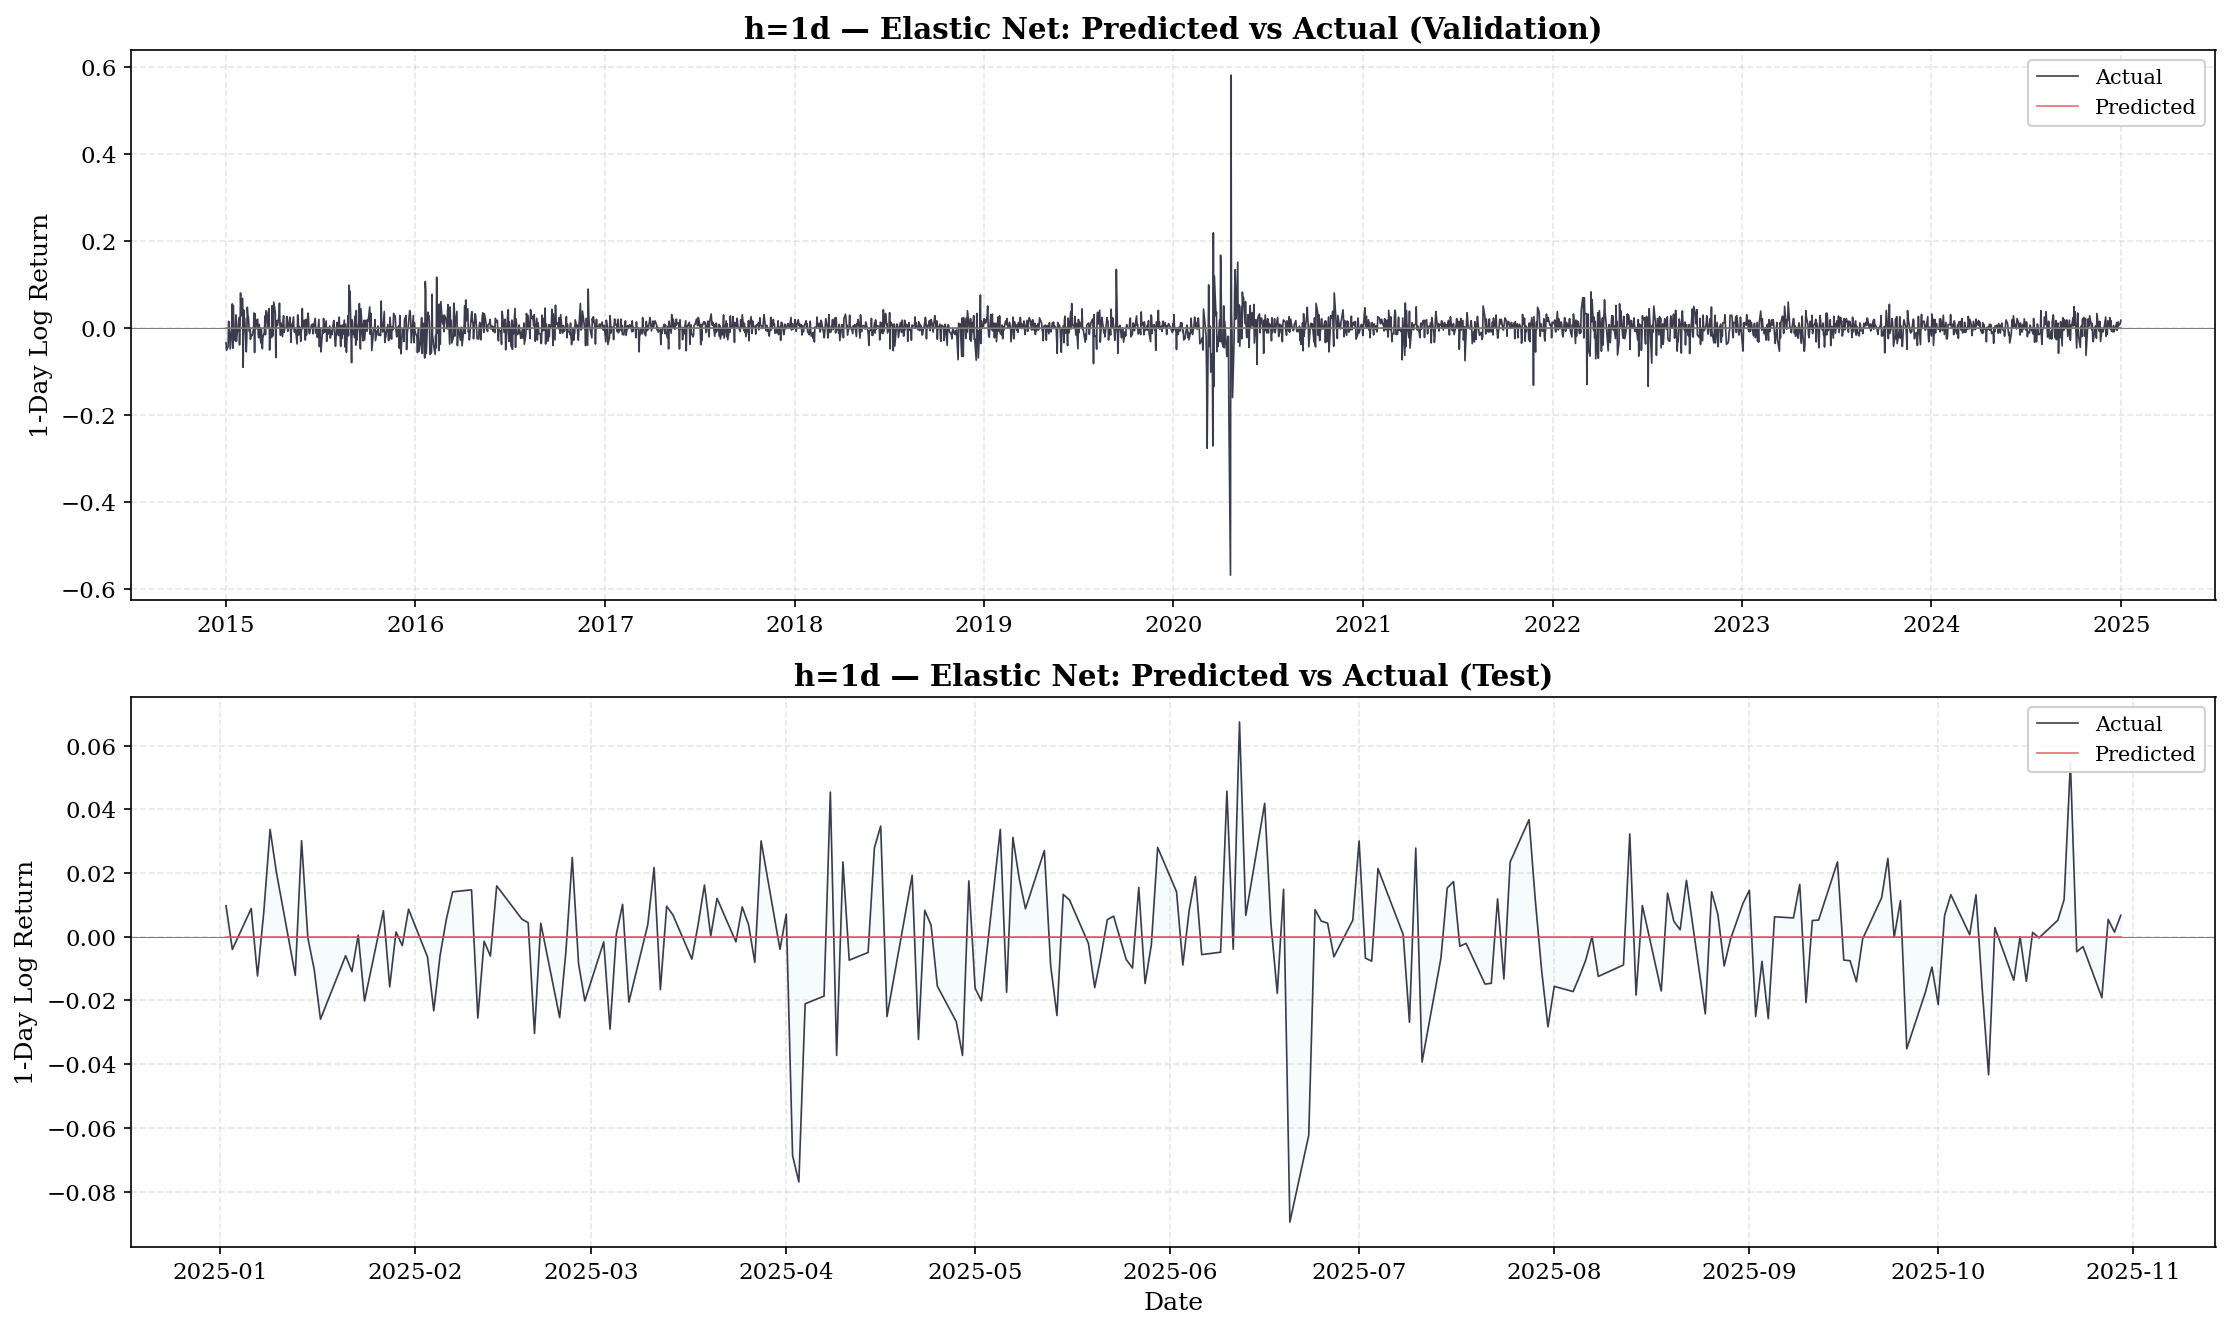

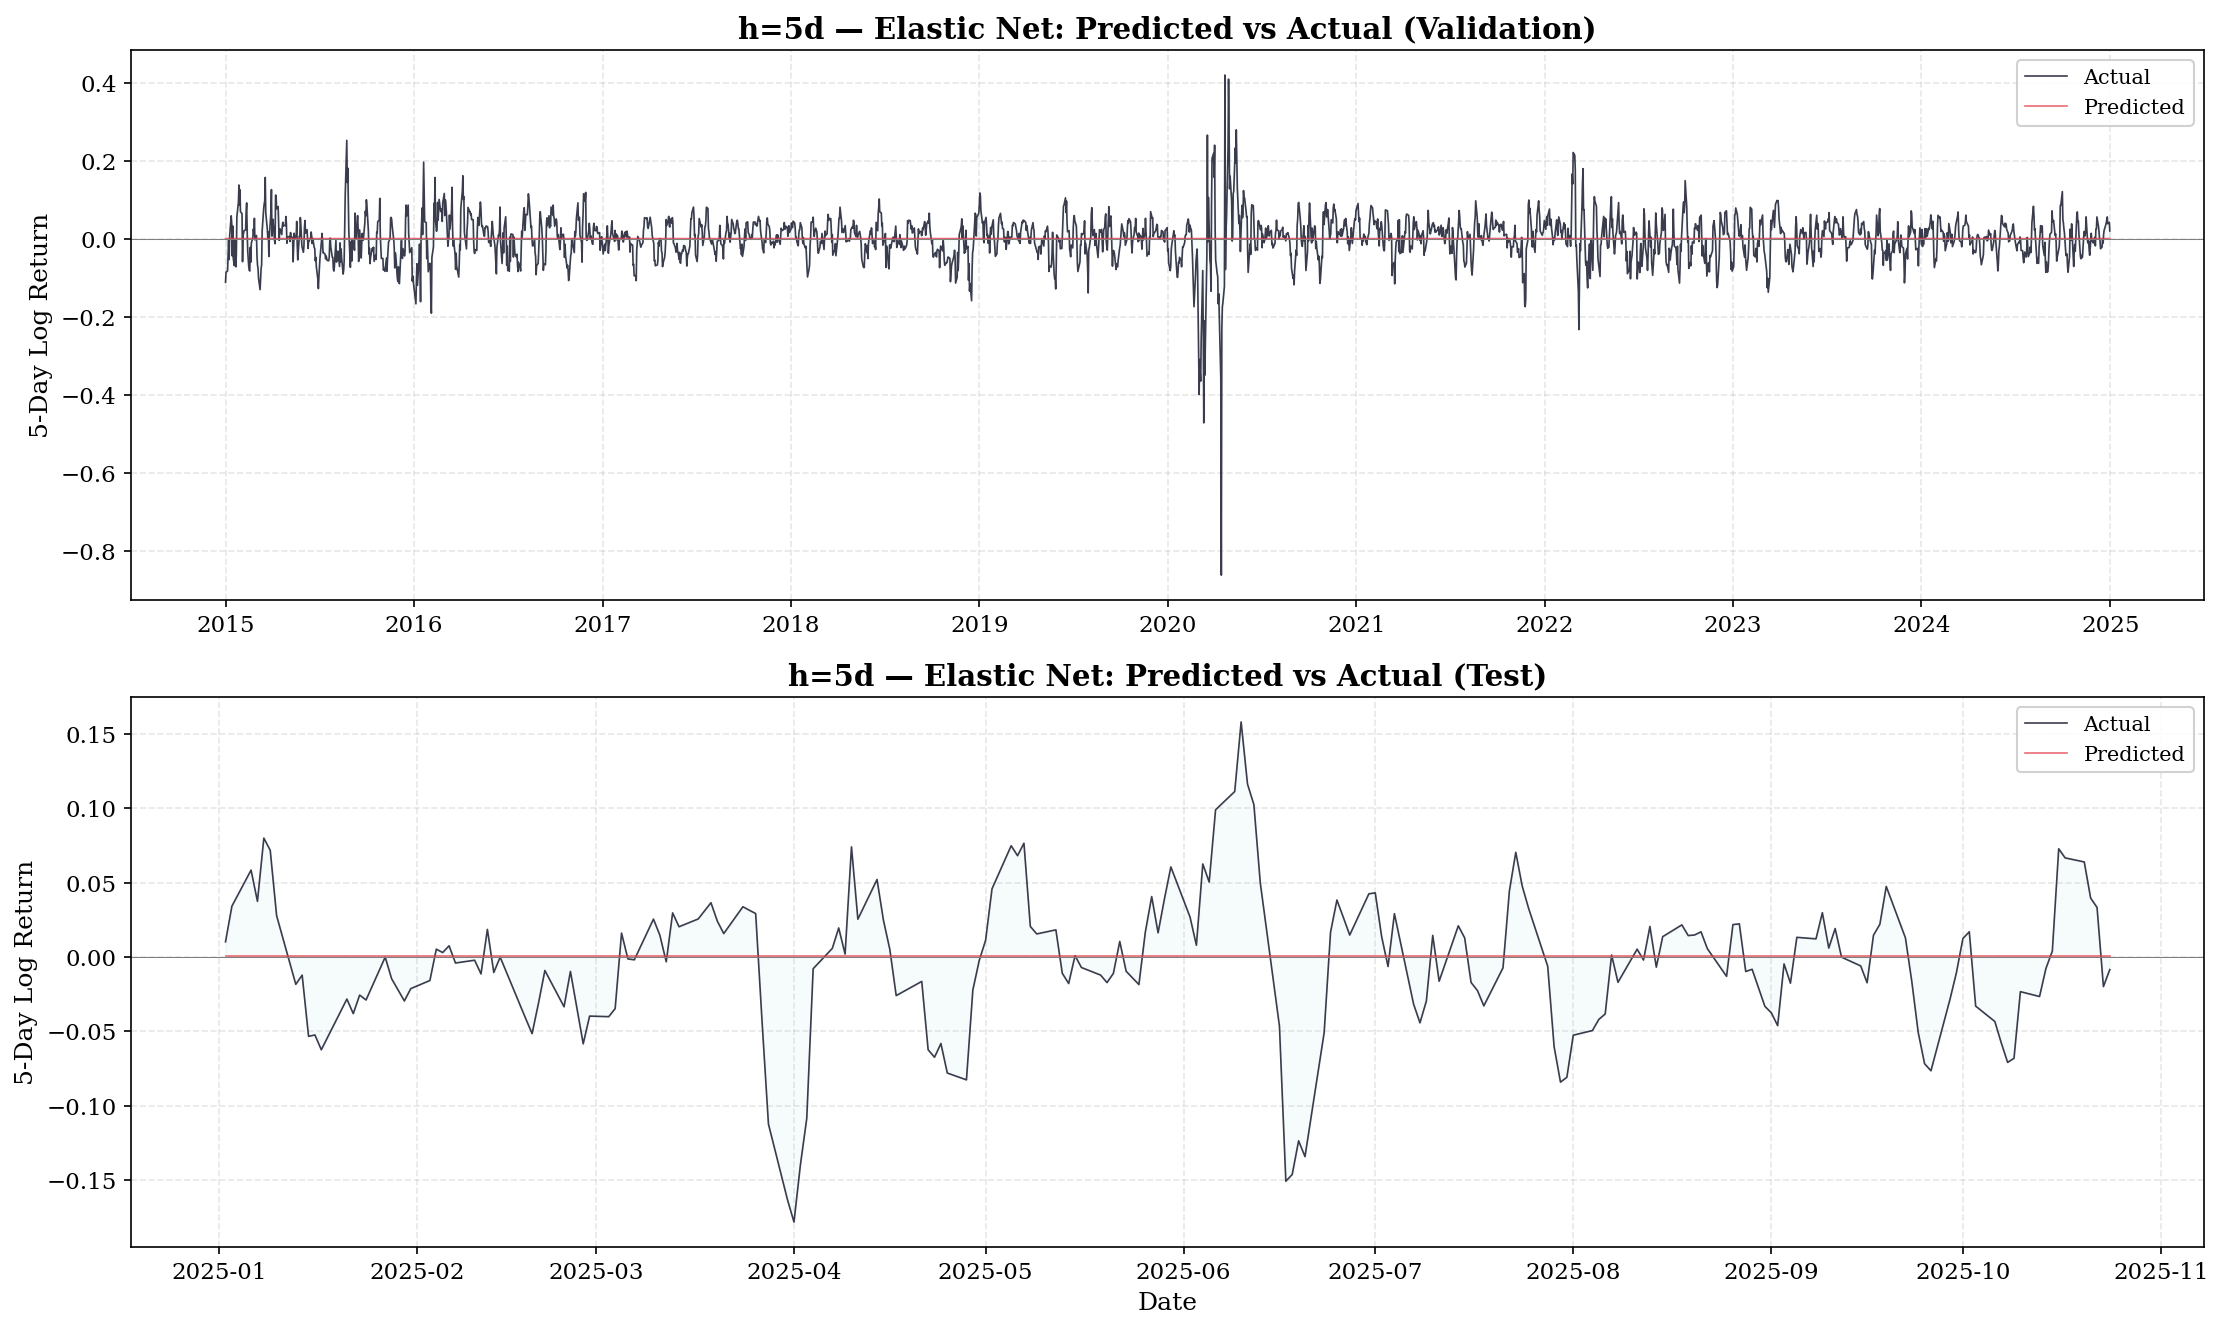

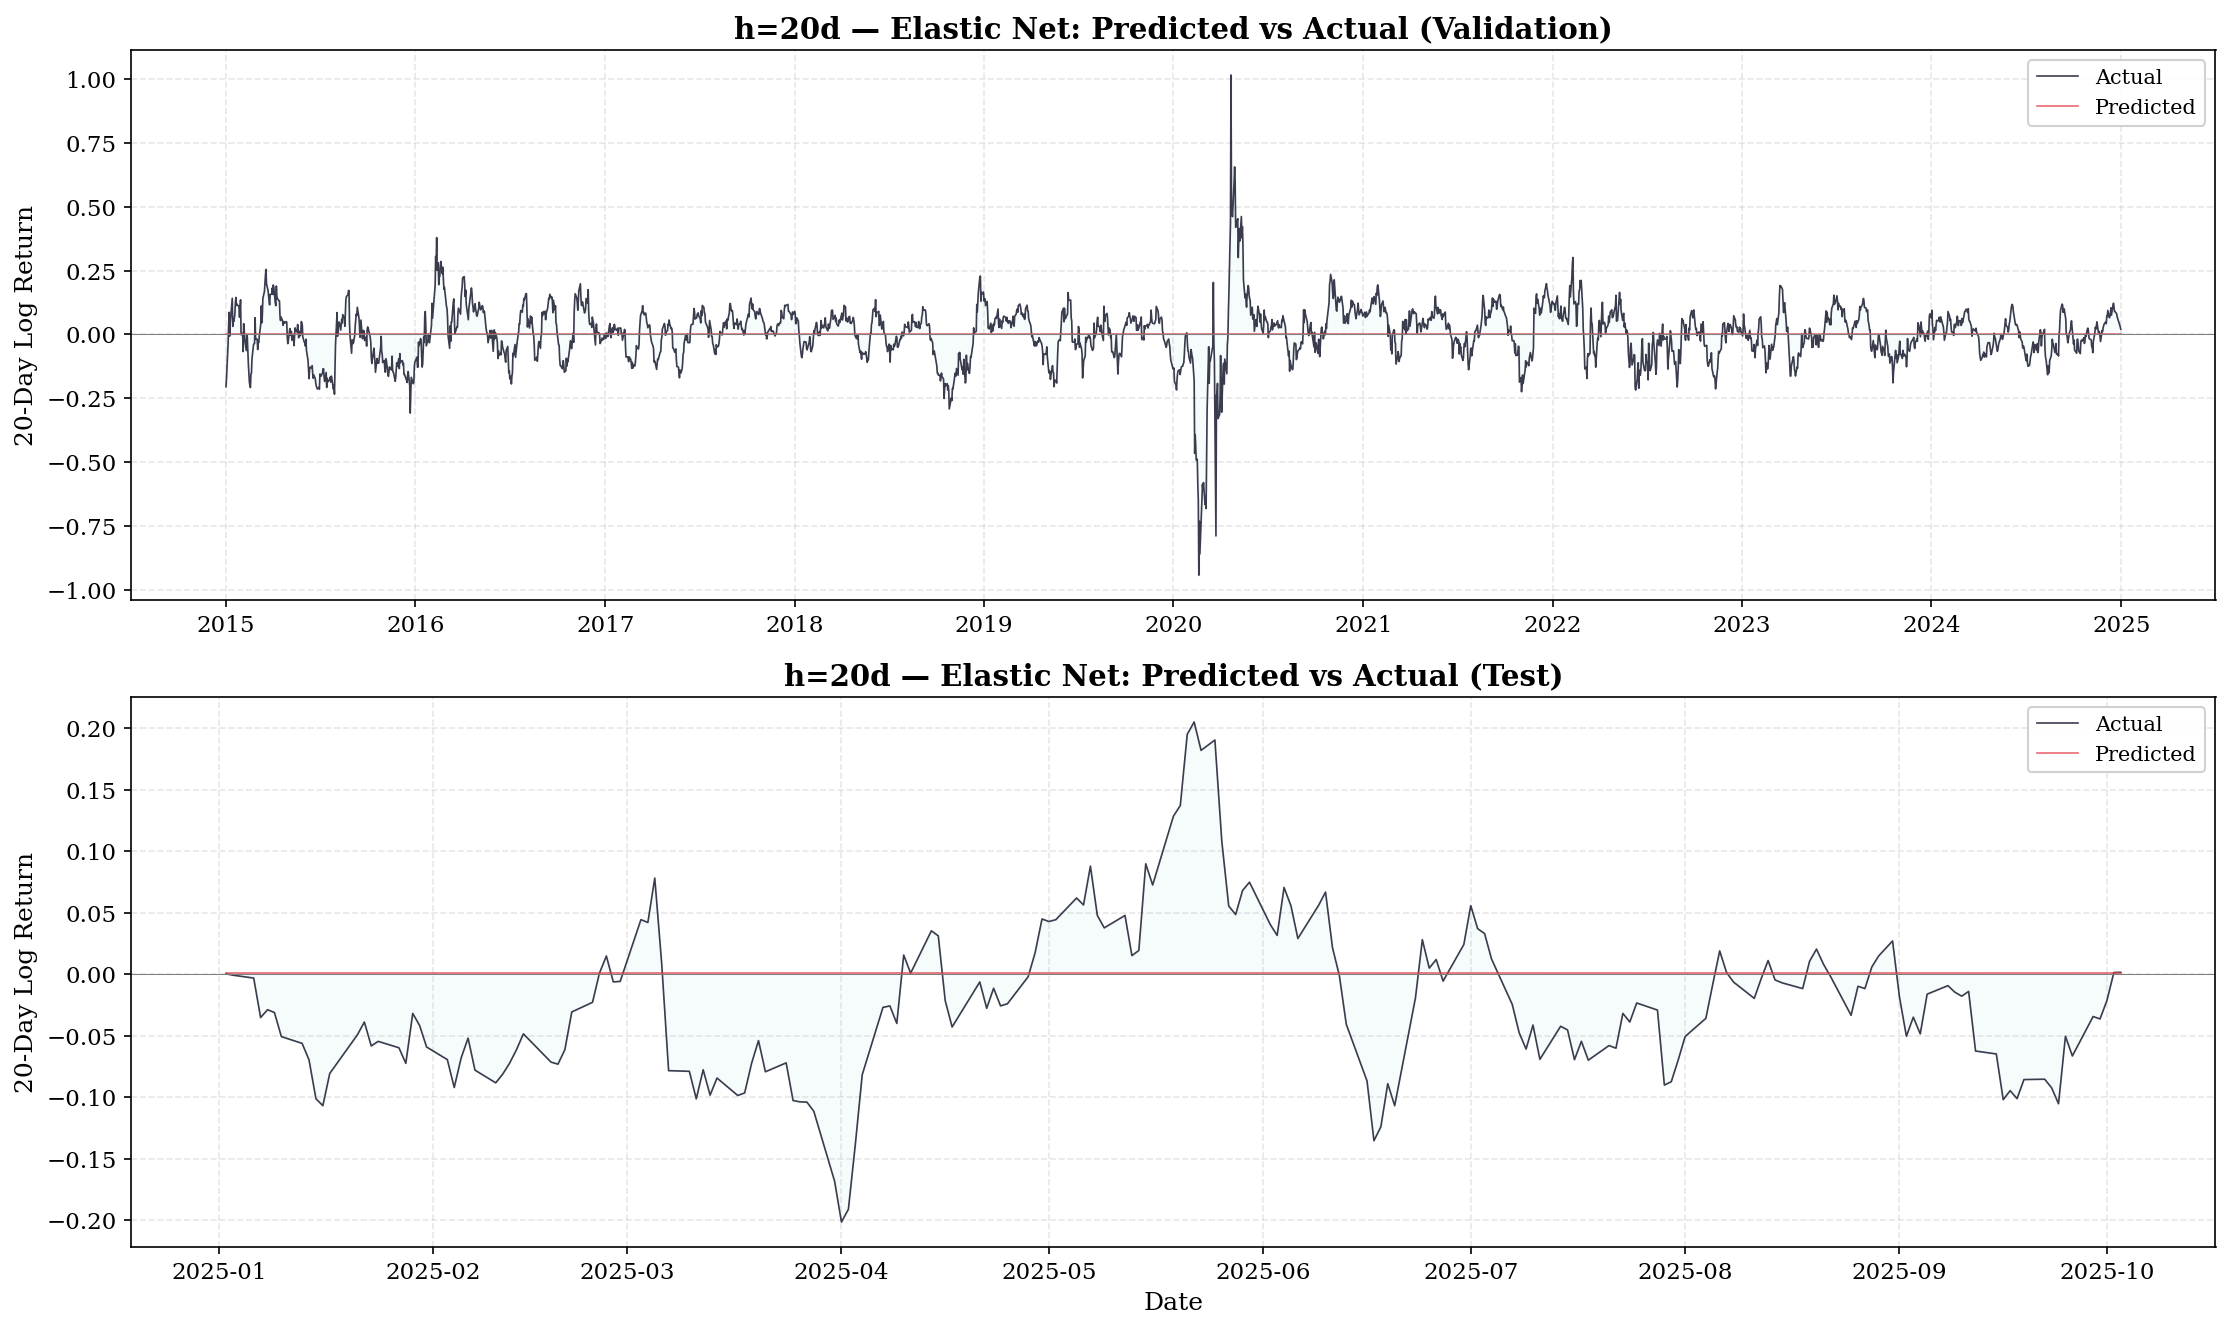

In [13]:
# ============================================================
# Predicted vs Actual — Time Series
# ============================================================
for h in HORIZONS:
    r = results[h]
    fig, axes = plt.subplots(2, 1, figsize=(15, 9))
    for ax, yt, yp, dates, label in [
        (axes[0], r['yva'].values, r['pred_val'], r['yva'].index, 'Validation'),
        (axes[1], r['yte'].values, r['pred_test'], r['yte'].index, 'Test'),
    ]:
        ax.plot(dates, yt, color=C['actual'], lw=0.8, alpha=0.85, label='Actual')
        ax.plot(dates, yp, color=C['pred'], lw=0.8, alpha=0.75, label='Predicted')
        ax.fill_between(dates, yt, yp, alpha=0.10, color=C['fill'])
        ax.axhline(0, color='gray', lw=0.5)
        ax.set_title(f'h={h}d — Elastic Net: Predicted vs Actual ({label})', fontweight='bold')
        ax.set_ylabel(f'{h}-Day Log Return')
        ax.legend(loc='upper right', framealpha=0.9)
    axes[1].set_xlabel('Date')
    plt.tight_layout()
    plt.show()

## 14. Coefficient Paths

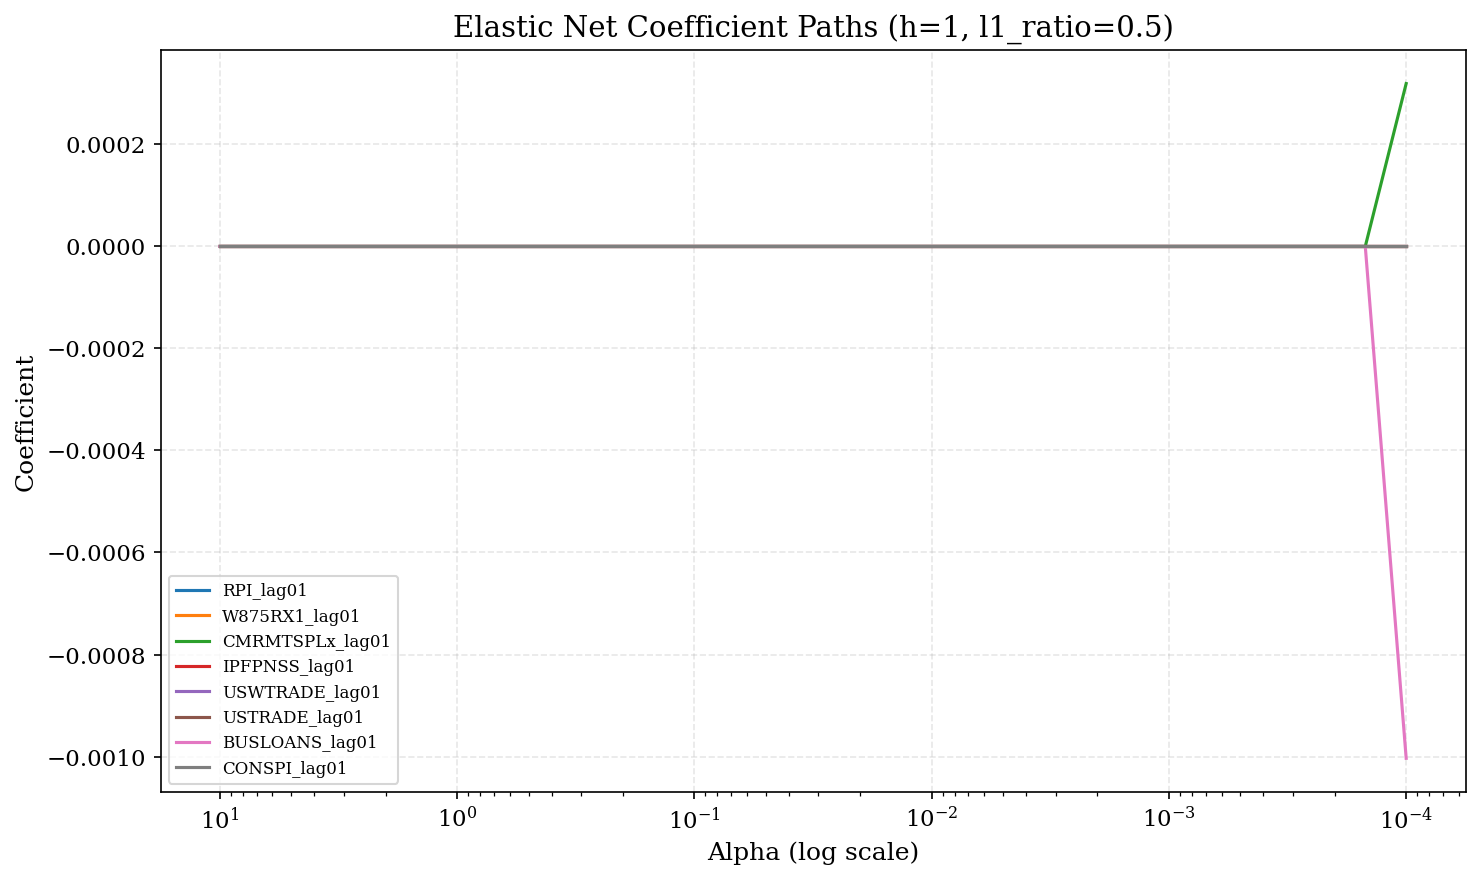

In [16]:
# ============================================================
# Coefficient Paths (for h=1)
# ============================================================
def plot_coef_paths(X, y, feature_names, l1_ratio=0.5):
    """Show how coefficients shrink to zero as alpha increases."""
    alphas = np.logspace(-4, 1, 30)
    coefs = []
    sc = StandardScaler()
    Xs = sc.fit_transform(X)
    for a in alphas:
        m = ElasticNet(alpha=a, l1_ratio=l1_ratio, max_iter=20000)
        m.fit(Xs, y)
        coefs.append(m.coef_)
    coefs = np.array(coefs)
    plt.figure(figsize=(10, 6))
    for i in range(min(8, coefs.shape[1])):
        plt.plot(alphas, coefs[:, i], label=feature_names[i])
    plt.xscale("log"); plt.gca().invert_xaxis()
    plt.xlabel("Alpha (log scale)"); plt.ylabel("Coefficient")
    plt.title("Elastic Net Coefficient Paths (h=1, l1_ratio=0.5)")
    plt.legend(fontsize=8); plt.tight_layout(); plt.show()

r1 = results[1]
plot_coef_paths(r1['Xtr'].values, r1['ytr'].values, r1['Xtr'].columns, l1_ratio=0.5)

## 15. CV RMSE vs Alpha

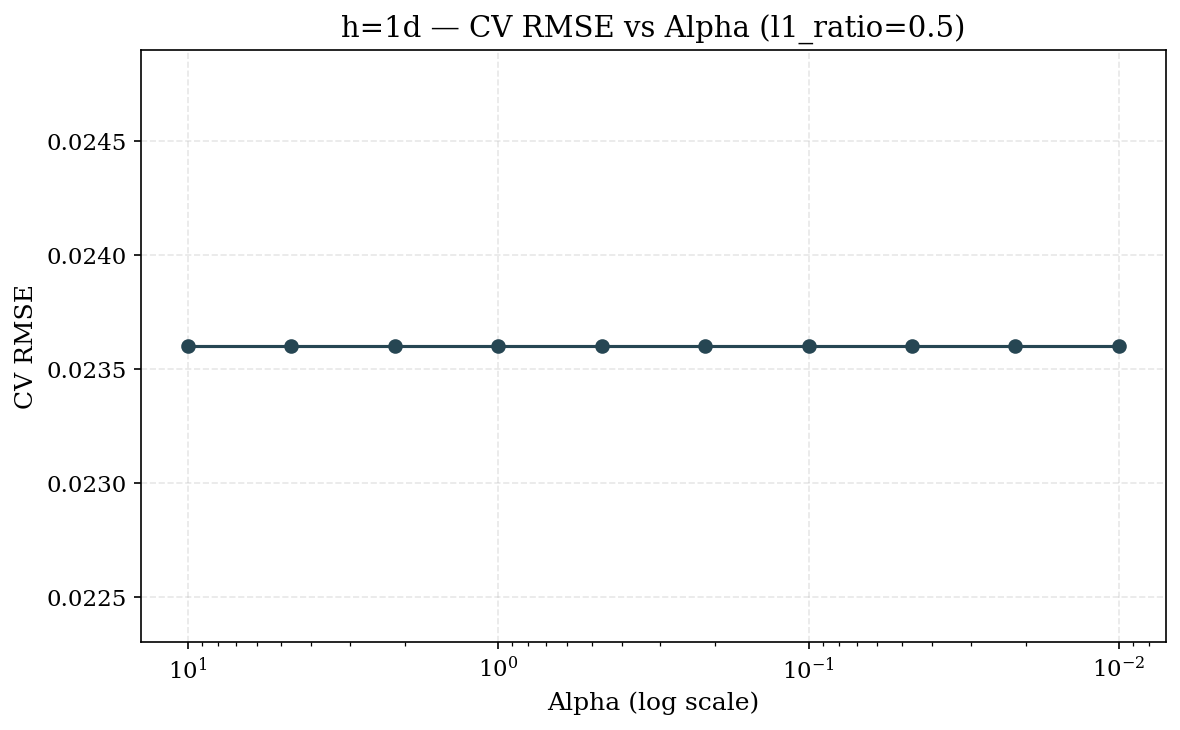

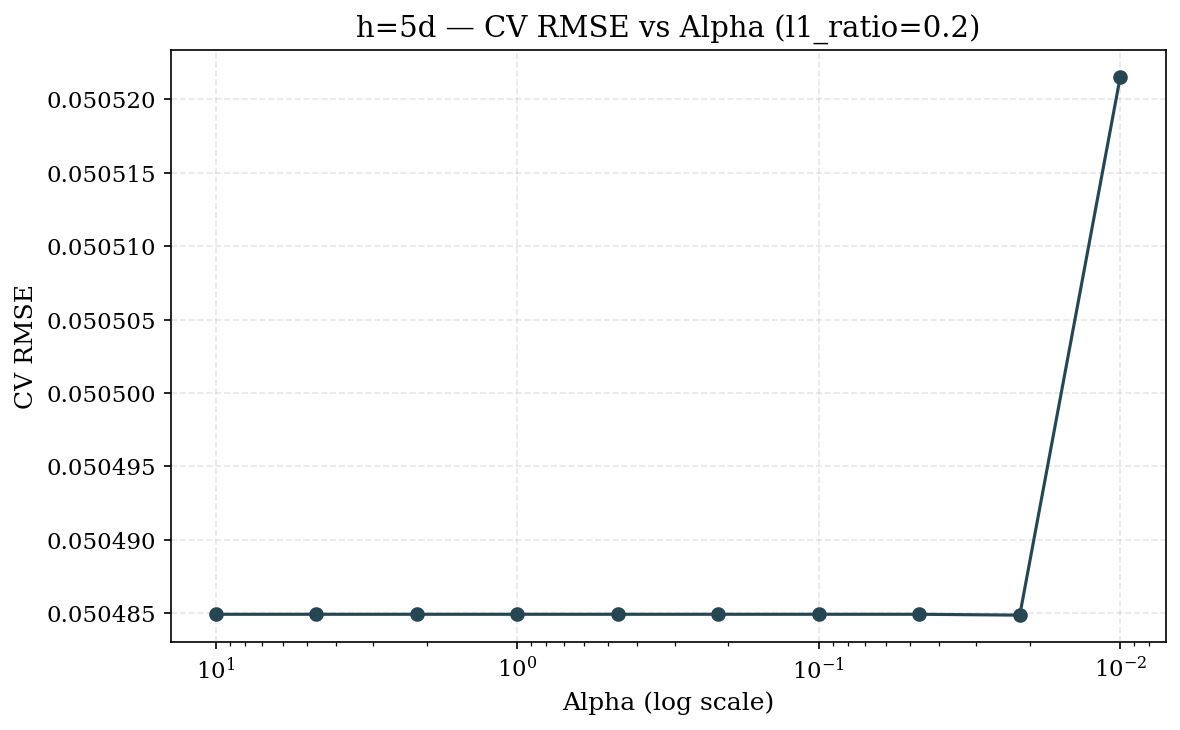

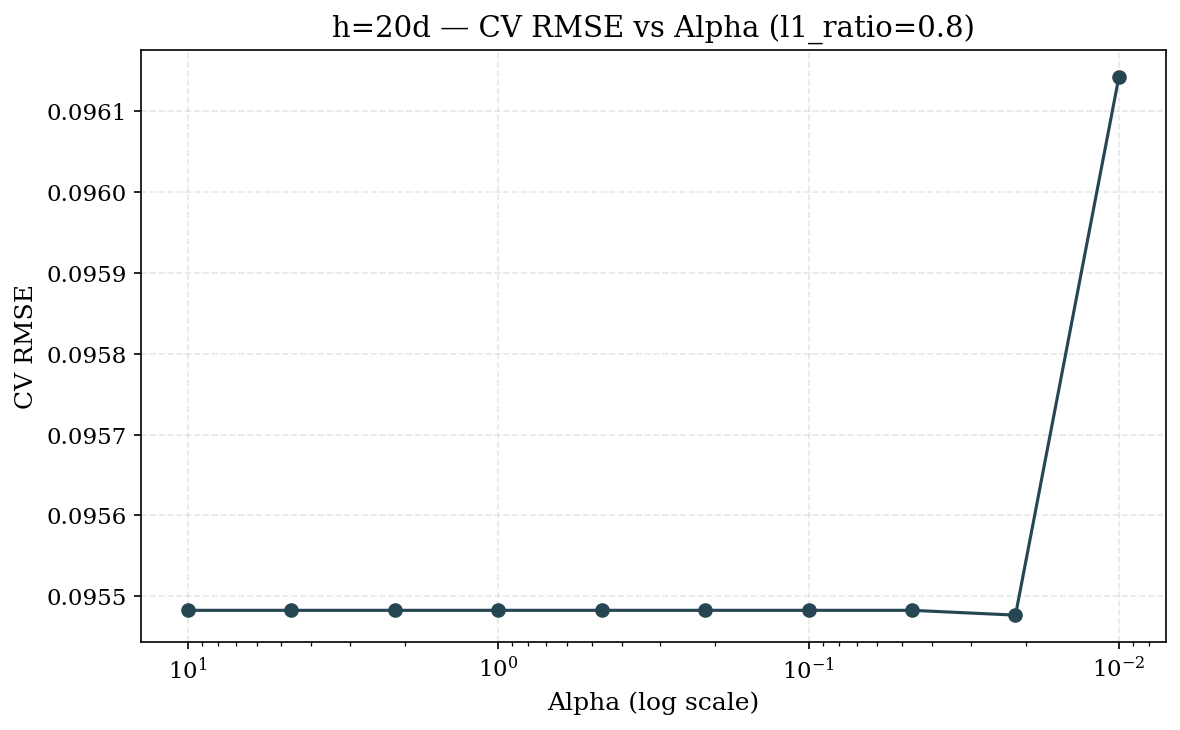

In [17]:
# ============================================================
# CV RMSE vs Alpha
# ============================================================
for h in HORIZONS:
    r = results[h]
    cv_df = pd.DataFrame(r['model'].cv_results_)
    l1 = r['model'].best_params_["l1_ratio"]
    df_plot = cv_df[cv_df["l1_ratio"] == l1]
    plt.figure(figsize=(8, 5))
    plt.plot(df_plot["alpha"], df_plot["rmse"], marker="o", color=C['h1'])
    plt.xscale("log"); plt.gca().invert_xaxis()
    plt.xlabel("Alpha (log scale)"); plt.ylabel("CV RMSE")
    plt.title(f"h={h}d — CV RMSE vs Alpha (l1_ratio={l1})")
    plt.tight_layout(); plt.show()

## 16. Multi-Horizon Comparison Bar Chart

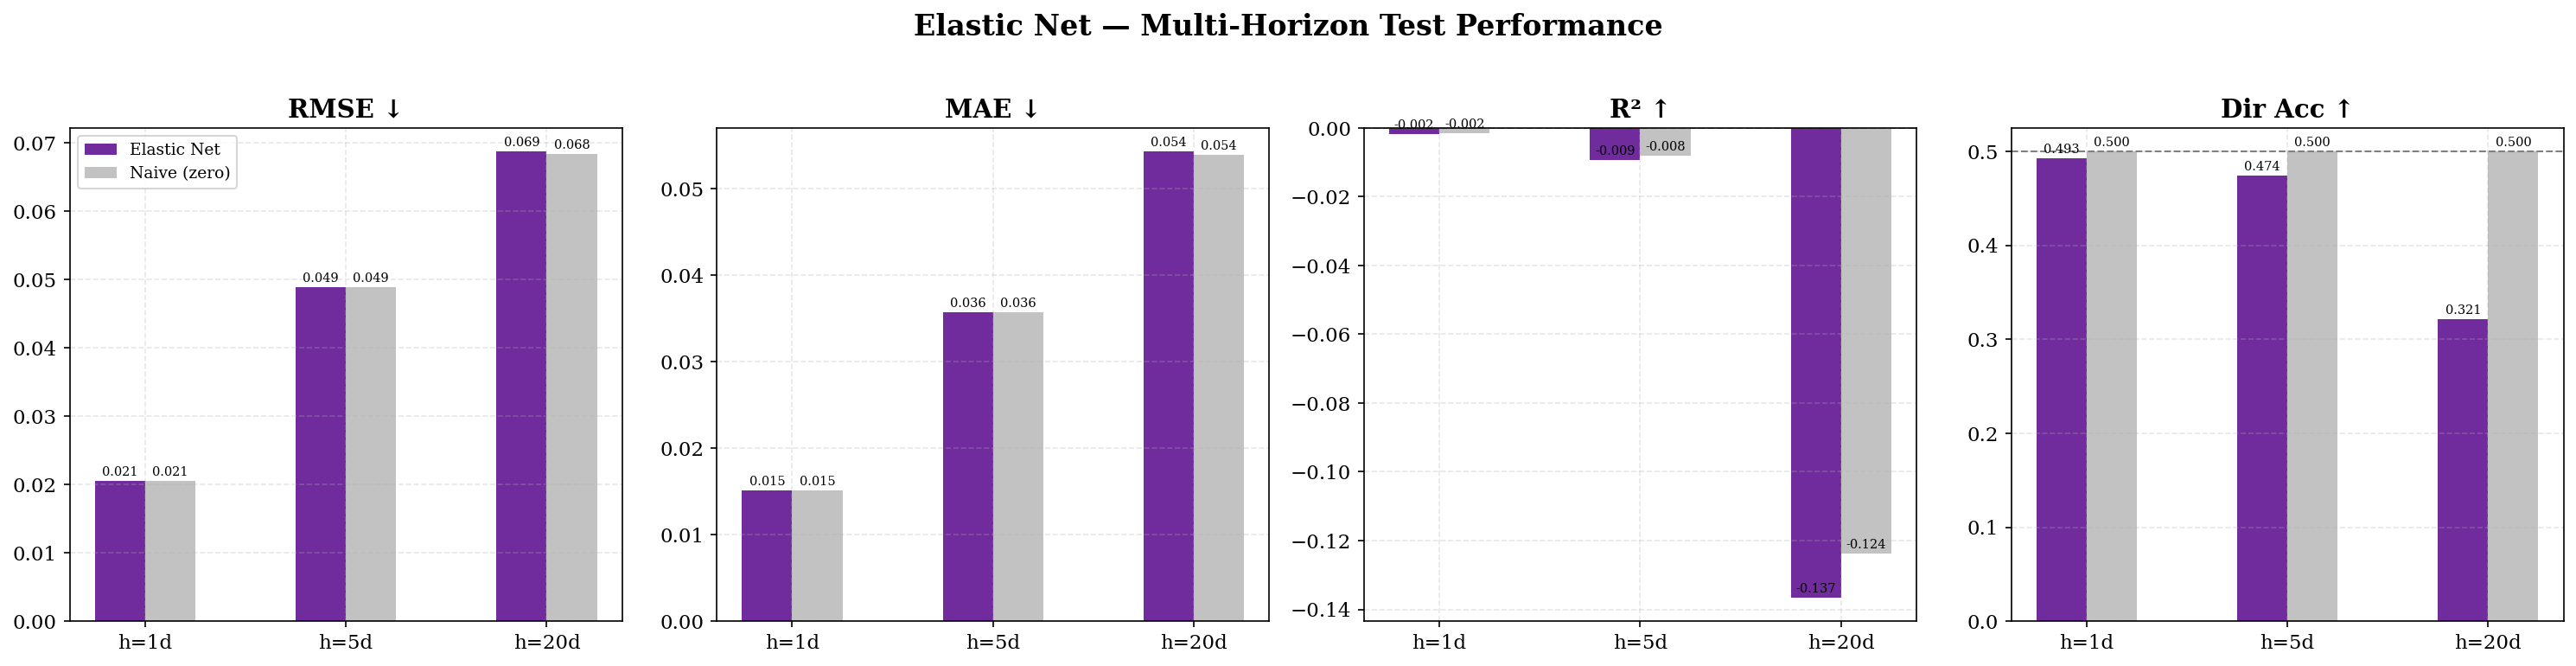

In [19]:
# ============================================================
# Multi-Horizon Comparison Bar Chart (EN vs Naive)
# ============================================================
met_names = ['rmse', 'mae', 'r2', 'directional_acc']
titles = ['RMSE ↓', 'MAE ↓', 'R² ↑', 'Dir Acc ↑']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
x = np.arange(len(HORIZONS))
w = 0.25

for i, (mn, title) in enumerate(zip(met_names, titles)):
    ax = axes[i]
    en_v  = [results[h]['test_metrics'][mn] for h in HORIZONS]
    nv_v  = [results[h]['naive_test'][mn] for h in HORIZONS]

    b1 = ax.bar(x - w/2, en_v, w, label='Elastic Net', color='#57068c', alpha=0.85)
    b2 = ax.bar(x + w/2, nv_v, w, label='Naive (zero)', color="#a8a8a8", alpha=0.7)

    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'h={h}d' for h in HORIZONS])
    if mn == 'directional_acc': ax.axhline(0.5, color='gray', ls='--', lw=1)
    elif mn == 'r2': ax.axhline(0, color='gray', ls='--', lw=1)
    for bar in list(b1) + list(b2):
        ht = bar.get_height()
        ax.annotate(f'{ht:.3f}', xy=(bar.get_x()+bar.get_width()/2, ht),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=7)
    if i == 0: ax.legend(fontsize=9)

plt.suptitle('Elastic Net — Multi-Horizon Test Performance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 17. Summary

In [18]:
# ============================================================
# Summary
# ============================================================
rows = []
for h in HORIZONS:
    for model_name, mk in [('EN', 'test_metrics'), ('Naive', 'naive_test')]:
        m = results[h][mk]
        rows.append({'Horizon': f'{h}d', 'Model': model_name,
            'RMSE': f"{m['rmse']:.6f}", 'MAE': f"{m['mae']:.6f}",
            'R²': f"{m['r2']:.6f}", 'Dir. Acc': f"{m['directional_acc']:.4f}"})

print(pd.DataFrame(rows).to_string(index=False))

print("\nBest hyperparameters:")
for h in HORIZONS:
    bp = results[h]['model'].best_params_
    print(f"  h={h:>2}d: alpha={bp['alpha']:.4f}, l1={bp['l1_ratio']}, cv_rmse={bp['cv_rmse']:.6f}")

Horizon Model     RMSE      MAE        R² Dir. Acc
     1d    EN 0.020522 0.015157 -0.001840   0.4930
     1d Naive 0.020519 0.015156 -0.001541   0.5000
     5d    EN 0.048925 0.035691 -0.009294   0.4739
     5d Naive 0.048894 0.035674 -0.008034   0.5000
    20d    EN 0.068749 0.054316 -0.136653   0.3214
    20d Naive 0.068357 0.053893 -0.123736   0.5000

Best hyperparameters:
  h= 1d: alpha=0.0100, l1=0.5, cv_rmse=0.023600
  h= 5d: alpha=0.0215, l1=0.2, cv_rmse=0.050485
  h=20d: alpha=0.0215, l1=0.8, cv_rmse=0.095477
